# MulticlassDisease Classification – XGBoost Optimization

## Problem Statement
This notebook develops and optimizes a multiclass disease classification model using XGBoost. The task is challenging because the target classes are imbalanced, meaning that some diseases are represented by many observations while others appear only rarely. In such settings, a model can achieve reasonable overall accuracy while still performing poorly on minority classes.

## Objective
The primary objective is to build a classification model that performs reliably across all disease categories, with particular emphasis on improving detection of minority classes. For this reason, macro F1-score is used as the main model selection criterion.

## Why Macro F1?
Macro F1 gives equal importance to every class, regardless of how often it appears in the dataset. This makes it more appropriate than accuracy for imbalanced multiclass classification, where strong performance on majority classes can otherwise hide poor minority-class detection.

## Modelling Strategy
The modelling workflow follows four stages:

1. Train a baseline XGBoost classifier to establish reference performance.
2. Introduce class weighting to reduce bias toward majority classes.
3. Perform hyperparameter tuning to improve class-balanced performance.
4. Compare candidate models using validation metrics and select the best model based on macro F1-score.

## Evaluation Criteria
The models are evaluated using:

- **Macro F1-score** — primary metric for balanced multiclass performance
- **Weighted F1-score** — accounts for class frequency while preserving class-level precision/recall balance
- **Accuracy** — included as a secondary global performance indicator

## Expected Contribution
This notebook aims not only to improve predictive performance, but also to explain how imbalance affects model behaviour, what trade-offs emerge during optimization, and why the final model is selected.

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from pathlib import Path

# Model preparation
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Model
import xgboost as xgb
from xgboost import XGBClassifier

# Reproducibility / display
RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## Data Loading

The modelling stage uses preprocessed train, validation, and test datasets prepared in the previous notebook.

The data split serves three distinct purposes:

- **Training set**: used to fit the model parameters
- **Validation set**: used for model comparison and selection
- **Test set**: held out until the end for unbiased final evaluation

This separation ensures that model decisions are made without leaking information from the final test set.

In [2]:
#  Data Loading and Preparation

def load_processed_data(path="../data/processed"):
    """
    Load preprocessed train, validation, and test datasets.

    Parameters:
        path (str): Directory path where processed CSV files are stored.

    Returns:
        train_df (pd.DataFrame)
        val_df (pd.DataFrame)
        test_df (pd.DataFrame)
    """
    train_df = pd.read_csv(f"{path}/train.csv")
    val_df = pd.read_csv(f"{path}/val.csv")
    test_df = pd.read_csv(f"{path}/test.csv")

    return train_df, val_df, test_df


def split_features_target(df, target_column="disease_encoded"):
    """
    Split a dataset into features (X) and target (y).

    Parameters:
        df (pd.DataFrame): Input dataset
        target_column (str): Name of the target column

    Returns:
        X (pd.DataFrame): Feature matrix
        y (pd.Series): Target vector
    """
    X = df.drop(columns=[target_column])
    y = df[target_column]
    return X, y


In [3]:
# Load datasets

train_df, val_df, test_df = load_processed_data()


# Split into features and target

X_train, y_train = split_features_target(train_df)
X_val, y_val = split_features_target(val_df)
X_test, y_test = split_features_target(test_df)


# Basic sanity checks

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nFeature matrix shape (train):", X_train.shape)
print("Target vector shape (train):", y_train.shape)

Train shape: (69906, 175)
Validation shape: (14980, 175)
Test shape: (14980, 175)

Feature matrix shape (train): (69906, 174)
Target vector shape (train): (69906,)


In [4]:
# 4. Evaluation Framework

def evaluate_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    model_name,
    sample_weight=None
):
    """
    Train a model, generate validation predictions, and compute evaluation metrics.

    Parameters:
        model: A fitted-compatible classification model
        X_train (pd.DataFrame): Training features
        y_train (pd.Series): Training labels
        X_val (pd.DataFrame): Validation features
        y_val (pd.Series): Validation labels
        model_name (str): Name used for reporting results
        sample_weight (array-like, optional): Sample weights for training

    Returns:
        results (dict): Summary evaluation metrics
        y_val_pred (np.ndarray): Validation predictions
    """

    # Train model
    if sample_weight is not None:
        model.fit(X_train, y_train, sample_weight=sample_weight)
    else:
        model.fit(X_train, y_train)

    # Predict on validation set
    y_val_pred = model.predict(X_val)

    # Compute evaluation metrics
    accuracy = accuracy_score(y_val, y_val_pred)
    f1_weighted = f1_score(y_val, y_val_pred, average="weighted")
    f1_macro = f1_score(y_val, y_val_pred, average="macro")

    # Print summary
    print(f"\n{model_name}")
    print("-" * len(model_name))
    print(f"Accuracy     : {accuracy:.4f}")
    print(f"Weighted F1  : {f1_weighted:.4f}")
    print(f"Macro F1     : {f1_macro:.4f}")

    results = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Weighted F1": f1_weighted,
        "Macro F1": f1_macro
    }

    return results, y_val_pred


# Initialize results storage
results_list = []

## Baseline Model: XGBoost

A baseline XGBoost classifier is first trained to establish a reference point before applying any imbalance-aware intervention or hyperparameter optimization.

XGBoost is selected as the baseline model for three reasons:

1. It performs strongly on structured tabular data.
2. It can capture non-linear relationships between features and the target.
3. It is robust, efficient, and widely used in real-world classification pipelines.

The purpose of the baseline model is not only to measure initial predictive performance, but also to diagnose how strongly class imbalance affects model behaviour before corrective measures are introduced.

In [5]:
def build_xgb_model(num_class, **params):
    
    base_params = {
        "objective": "multi:softprob",
        "num_class": num_class,
        "eval_metric": "mlogloss",
        "random_state": RANDOM_STATE,
        "tree_method": "hist",
        "n_jobs": -1
    }

    base_params.update(params)
    return XGBClassifier(**base_params)

In [6]:
# Define baseline hyperparameters
baseline_params = {
    "n_estimators": 300,
    "max_depth": 8,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8
}

# Number of classes from the target variable
num_class = y_train.nunique()

# Build baseline model
xgb_base = build_xgb_model(num_class=num_class, **baseline_params)

# Evaluate baseline model using the standard evaluation function
baseline_results, y_val_pred_base = evaluate_model(
    model=xgb_base,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    model_name="XGBoost (Baseline)"
)

# Store results
results_list.append(baseline_results)

# Display results
results_df = pd.DataFrame(results_list).sort_values(by="Macro F1", ascending=False)
display(results_df)


XGBoost (Baseline)
------------------
Accuracy     : 0.6652
Weighted F1  : 0.6550
Macro F1     : 0.4592


,Model,Accuracy,Weighted F1,Macro F1
0,XGBoost (Baseline),0.6652,0.6550,0.4592


In [7]:


report_dict = classification_report(
    y_val,
    y_val_pred_base,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

report_df

,precision,recall,f1-score,support
0,0.3333,0.1250,0.1818,8.0000
1,0.6698,0.8754,0.7589,3195.0000
2,0.6277,0.3819,0.4748,309.0000
3,0.6051,0.3869,0.4720,305.0000
4,0.6758,0.5955,0.6331,749.0000
5,0.6820,0.4418,0.5362,335.0000
6,0.6867,0.4101,0.5135,139.0000
7,0.8000,1.0000,0.8889,24.0000
8,0.6437,0.4569,0.5345,348.0000
9,0.3333,0.3333,0.3333,3.0000


In [8]:
# sort by worst performing classes (recall)
report_df.sort_values(by="recall").head(10)

,precision,recall,f1-score,support
28,0.0000,0.0000,0.0000,10.0000
26,0.0000,0.0000,0.0000,10.0000
22,0.0000,0.0000,0.0000,7.0000
18,0.0000,0.0000,0.0000,5.0000
13,0.0000,0.0000,0.0000,14.0000
0,0.3333,0.1250,0.1818,8.0000
27,0.5000,0.1304,0.2069,23.0000
19,0.6957,0.2286,0.3441,70.0000
9,0.3333,0.3333,0.3333,3.0000
14,0.6519,0.3563,0.4607,247.0000


In [9]:
low_recall = report_df[report_df["recall"] < 0.3]
low_recall

,precision,recall,f1-score,support
0,0.3333,0.1250,0.1818,8.0000
13,0.0000,0.0000,0.0000,14.0000
18,0.0000,0.0000,0.0000,5.0000
19,0.6957,0.2286,0.3441,70.0000
22,0.0000,0.0000,0.0000,7.0000
26,0.0000,0.0000,0.0000,10.0000
27,0.5000,0.1304,0.2069,23.0000
28,0.0000,0.0000,0.0000,10.0000


The model achieves 0.6652 accuracy and 0.6550 weighted F1, but a much lower macro F1 of 0.4592.

This gap shows that performance is not balanced across classes.

The model performs well on majority classes
Minority classes are poorly learned, with very low recall

Conclusion:
The model is biased toward majority classes, and accuracy is overstating true performance.

Implication:
Class imbalance is the key issue, requiring imbalance-aware training (e.g., class weighting).

---

## Handling Class Imbalance

Apply class weighting to penalize errors on minority classes more heavily during training.

In [10]:

# Compute class weights
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

# Convert to dictionary
class_weights = dict(zip(classes, weights))

# Create sample weights for each training example
sample_weights = np.array([class_weights[y] for y in y_train])

# Number of classes from the target variable
num_class = y_train.nunique()

# Build weighted XGBoost model (same parameters as baseline)
xgb_weighted = build_xgb_model(
    num_class=num_class,
    **baseline_params
)

# Evaluate weighted model
weighted_results, y_val_pred_weighted = evaluate_model(
    model=xgb_weighted,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    model_name="XGBoost (Weighted)",
    sample_weight=sample_weights
)

# Store results
results_list.append(weighted_results)

# Show comparison
results_df = pd.DataFrame(results_list).sort_values(by="Macro F1", ascending=False)
display(results_df)


XGBoost (Weighted)
------------------
Accuracy     : 0.6558
Weighted F1  : 0.6577
Macro F1     : 0.4809


,Model,Accuracy,Weighted F1,Macro F1
1,XGBoost (Weighted),0.6558,0.6577,0.4809
0,XGBoost (Baseline),0.6652,0.6550,0.4592


In [11]:
# Classification report for weighted model
report_dict_weighted = classification_report(
    y_val,
    y_val_pred_weighted,
    output_dict=True,
    zero_division=0
)


report_df_weighted = pd.DataFrame(report_dict_weighted).transpose()
report_df_weighted


,precision,recall,f1-score,support
0,0.2857,0.2500,0.2667,8.0000
1,0.8013,0.7083,0.7520,3195.0000
2,0.5290,0.5307,0.5299,309.0000
3,0.5279,0.5279,0.5279,305.0000
4,0.6257,0.6382,0.6319,749.0000
5,0.6017,0.6179,0.6097,335.0000
6,0.4880,0.5827,0.5311,139.0000
7,0.7500,1.0000,0.8571,24.0000
8,0.5167,0.5776,0.5455,348.0000
9,0.2500,0.3333,0.2857,3.0000


In [12]:
class_report_weighted = report_df_weighted.loc[
    ~report_df_weighted.index.isin(["accuracy", "macro avg", "weighted avg"])
].copy()

# Show worst classes
display(class_report_weighted.sort_values(by="recall").head(10))


,precision,recall,f1-score,support
26,0.0000,0.0000,0.0000,10.0000
22,0.0000,0.0000,0.0000,7.0000
18,0.0000,0.0000,0.0000,5.0000
13,0.0000,0.0000,0.0000,14.0000
28,0.5000,0.1000,0.1667,10.0000
0,0.2857,0.2500,0.2667,8.0000
9,0.2500,0.3333,0.2857,3.0000
27,0.4444,0.3478,0.3902,23.0000
19,0.3714,0.3714,0.3714,70.0000
14,0.5339,0.5101,0.5217,247.0000


In [13]:

# Show low recall classes
low_recall_weighted = class_report_weighted[class_report_weighted["recall"] < 0.30]
display(low_recall_weighted)

,precision,recall,f1-score,support
0,0.2857,0.2500,0.2667,8.0000
13,0.0000,0.0000,0.0000,14.0000
18,0.0000,0.0000,0.0000,5.0000
22,0.0000,0.0000,0.0000,7.0000
26,0.0000,0.0000,0.0000,10.0000
28,0.5000,0.1000,0.1667,10.0000



The weighted model reduces accuracy slightly (0.6558 vs 0.6652) but improves macro F1 from 0.4592 → 0.4809.

This indicates better balance across classes, especially improved learning of minority classes.

- Weighted F1 increases → overall performance remains stable
- Macro F1 improves → minority class performance improves
- Accuracy drops slightly → expected trade-off

Conclusion:
Class weighting successfully reduces majority bias and improves fairness across classes, with minimal impact on overall performance.

Implication:
The model is now more reliable for imbalanced classification and better aligned with the objective of detecting all classes.

---


## Hyperparameter Tuning

Optimize XGBoost hyperparameters using randomized search with stratified cross-validation, targeting macro F1-score.

In [14]:


# Number of classes from the target variable
num_class = y_train.nunique()
# Hyperparameter search space for XGBoost
# These parameters control model complexity, learning behavior, and regularization.
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
    "reg_alpha": [0, 0.01, 0.1],
    "reg_lambda": [1, 1.5, 2]
}

# Stratified cross-validation preserves class distribution in each fold,
# which is important for imbalanced multiclass classification.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# RandomizedSearchCV is used instead of exhaustive GridSearchCV to balance
# search quality and computational cost across a large parameter space.
search = RandomizedSearchCV(
    estimator=build_xgb_model(num_class=num_class),
    param_distributions=param_dist,
    n_iter=15,
    scoring="f1_macro",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    refit=True
)

# Fit the randomized search on the training data.
# Sample weights are included so that class imbalance handling is preserved
# during hyperparameter optimization.
search.fit(
    X_train,
    y_train,
    sample_weight=sample_weights,
    verbose=False
)

# Display the best cross-validated result and corresponding parameter set.
print("\nBest CV Macro F1:", round(search.best_score_, 4))
print("Best Parameters:")
print(search.best_params_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.05, max_depth=5, min_child_weight=1, n_estimators=100, reg_alpha=0.01, reg_lambda=2, subsample=0.9; total time= 2.5min
[CV] END colsample_bytree=0.9, gamma=0.3, learning_rate=0.2, max_depth=5, min_child_weight=5, n_estimators=200, reg_alpha=0.1, reg_lambda=2, subsample=0.7; total time= 4.8min
[CV] END colsample_bytree=0.9, gamma=0.3, learning_rate=0.2, max_depth=5, min_child_weight=5, n_estimators=200, reg_alpha=0.1, reg_lambda=2, subsample=0.7; total time= 4.8min
[CV] END colsample_bytree=0.9, gamma=0.3, learning_rate=0.2, max_depth=5, min_child_weight=5, n_estimators=200, reg_alpha=0.1, reg_lambda=2, subsample=0.7; total time= 4.9min
[CV] END colsample_bytree=0.9, gamma=0.3, learning_rate=0.2, max_depth=5, min_child_weight=5, n_estimators=200, reg_alpha=0.1, reg_lambda=2, subsample=0.7; total time= 4.8min
[CV] END colsample_bytree=0.9, gamma=0.3, learning_rate=0.2, max

In [15]:
# Retrieve the best tuned model from randomized search
best_model = search.best_estimator_

# Predict on validation set
y_val_pred_tuned = best_model.predict(X_val)

# Compute metrics manually
tuned_results = {
    "Model": "Tuned XGBoost + Class Weights",
    "Accuracy": accuracy_score(y_val, y_val_pred_tuned),
    "Weighted F1": f1_score(y_val, y_val_pred_tuned, average="weighted"),
    "Macro F1": f1_score(y_val, y_val_pred_tuned, average="macro")
}

# Store results
results_list.append(tuned_results)
# Create directory
output_dir = Path("../results/tables")
output_dir.mkdir(parents=True, exist_ok=True)

# Save results table
results_df.to_csv(output_dir / "model_comparison.csv", index=False)

print(f"Results table saved to: {output_dir / 'model_comparison.csv'}")

# Display comparison
results_df = pd.DataFrame(results_list).sort_values(by="Macro F1", ascending=False)
display(results_df)

Results table saved to: ../results/tables/model_comparison.csv


,Model,Accuracy,Weighted F1,Macro F1
2,Tuned XGBoost + Class Weights,0.6531,0.6630,0.5145
1,XGBoost (Weighted),0.6558,0.6577,0.4809
0,XGBoost (Baseline),0.6652,0.6550,0.4592


In [16]:
# Classification report for weighted tuned model
report_dict_tuned = classification_report(
    y_val,
    y_val_pred_tuned,
    output_dict=True,
    zero_division=0
)

report_df_tuned = pd.DataFrame(report_dict_tuned).transpose()

report_df_tuned

,precision,recall,f1-score,support
0,0.4286,0.7500,0.5455,8.0000
1,0.9146,0.5668,0.6999,3195.0000
2,0.4901,0.7217,0.5838,309.0000
3,0.4692,0.7246,0.5696,305.0000
4,0.6474,0.6716,0.6592,749.0000
5,0.5010,0.7761,0.6089,335.0000
6,0.3423,0.8201,0.4831,139.0000
7,0.7500,1.0000,0.8571,24.0000
8,0.4847,0.7270,0.5816,348.0000
9,0.2500,0.3333,0.2857,3.0000


In [17]:
class_report_tuned = report_df_tuned.loc[
    ~report_df_tuned.index.isin(["accuracy", "macro avg", "weighted avg"])
].copy()

# Show worst classes
display(class_report_tuned.sort_values(by="recall").head(10))

,precision,recall,f1-score,support
18,0.0000,0.0000,0.0000,5.0000
13,0.0000,0.0000,0.0000,14.0000
26,0.2500,0.1000,0.1429,10.0000
22,0.1111,0.1429,0.1250,7.0000
28,0.5000,0.3000,0.3750,10.0000
9,0.2500,0.3333,0.2857,3.0000
27,0.3529,0.5217,0.4211,23.0000
1,0.9146,0.5668,0.6999,3195.0000
17,0.7646,0.5879,0.6647,1354.0000
15,0.8108,0.6141,0.6989,1612.0000


In [18]:
# Show low recall classes
low_recall_tuned = class_report_tuned[class_report_tuned["recall"] < 0.30]
display(low_recall_tuned)

,precision,recall,f1-score,support
13,0.0000,0.0000,0.0000,14.0000
18,0.0000,0.0000,0.0000,5.0000
22,0.1111,0.1429,0.1250,7.0000
26,0.2500,0.1000,0.1429,10.0000


## Tuned Model Performance Interpretation

### Performance Summary
- Accuracy: 0.6531  
- Weighted F1: 0.6630  
- Macro F1: 0.5145  

### Key Improvements
The tuned XGBoost model with class weighting delivers a clear improvement in class-balanced performance:

- Macro F1 increases from **0.4592 → 0.5145**
- Weighted F1 improves slightly, indicating stable overall performance
- Accuracy decreases marginally, which is expected in imbalance-aware optimization

### Interpretation
The improvement in macro F1 indicates that the model is now significantly better at learning minority classes. Unlike the baseline model, which was biased toward majority classes, the tuned model distributes learning more evenly across all classes.

This shift suggests that:
- Class weighting reduces bias toward dominant classes  
- Hyperparameter tuning improves the model’s ability to capture minority class patterns  

### Trade-off Analysis
The slight drop in accuracy reflects a deliberate trade-off:
- Less focus on majority classes  
- Better performance across all classes  

This is desirable in imbalanced classification problems, where accuracy alone can be misleading.

### Conclusion
The tuned model achieves the best balance between overall performance and class fairness. It is more reliable for imbalanced multiclass classification and better aligned with the objective of detecting all disease categories.

---

## Final Model Selection



The tuned XGBoost model with class weighting achieves the best overall balance, with a macro F1 of 0.5145, improving consistently from the baseline (0.4592) and weighted model (0.4809).

Key Observations
- Macro F1 improves significantly → better minority class detection
- Weighted F1 increases to 0.6630 → overall performance remains strong
- Accuracy decreases slightly → expected trade-off

Interpretation
- Baseline model prioritized majority classes
- Class weighting reduced this bias
-Hyperparameter tuning further improved class-balanced learning

Conclusion

The final model provides the best trade-off between overall performance and class fairness.
It is more reliable for imbalanced classification, where equal performance across classes is critical.

---

## Final Model Evaluation (Test Set)

In [19]:
# Correct: derive number of classes from training data
num_class = y_train.nunique()

# Final selected model: weighted XGBoost
final_model = search.best_estimator_

# Train on training set
final_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

# Predict on test set
y_test_pred = final_model.predict(X_test)

from sklearn.metrics import accuracy_score, f1_score, classification_report

# Compute metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1_weighted = f1_score(y_test, y_test_pred, average="weighted")
test_f1_macro = f1_score(y_test, y_test_pred, average="macro")

# Store results
final_test_results = {
    "Model": "Final Weighted XGBoost (Test)",
    "Accuracy": test_accuracy,
    "Weighted F1": test_f1_weighted,
    "Macro F1": test_f1_macro
}

# Display
final_test_results_df = pd.DataFrame([final_test_results])
display(final_test_results_df)

# Classification report
print("Test Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

,Model,Accuracy,Weighted F1,Macro F1
0,Final Weighted XGBoost (Test),0.6543,0.6636,0.5325


Test Classification Report:
              precision    recall  f1-score   support

           0       0.20      0.29      0.24         7
           1       0.91      0.55      0.68      3194
           2       0.49      0.79      0.60       309
           3       0.46      0.67      0.55       305
           4       0.65      0.70      0.67       749
           5       0.51      0.73      0.60       336
           6       0.34      0.78      0.47       138
           7       0.89      1.00      0.94        25
           8       0.47      0.69      0.56       348
           9       0.30      0.75      0.43         4
          10       0.37      0.75      0.49        55
          11       0.60      0.75      0.67       516
          12       0.59      0.71      0.64       665
          13       0.21      0.29      0.24        14
          14       0.44      0.71      0.55       247
          15       0.81      0.64      0.71      1612
          16       0.36      0.74      0.49       253

## Final Test Set Performance

The final tuned XGBoost model with class weighting achieved strong and stable performance on the test set:

- Accuracy: 0.6543  
- Weighted F1: 0.6636  
- Macro F1: 0.5325  

The macro F1-score on the test set is higher than both the baseline and weighted validation models, confirming that the tuned model generalizes well and provides better balanced performance across classes.

This result shows that the final model is not only effective on the validation set, but also remains reliable on unseen data. The improvement in macro F1 indicates stronger minority class detection, while the weighted F1-score confirms that overall performance is preserved.

Overall, the tuned model with class weighting provides the best balance between class fairness and predictive performance, making it the most suitable final model for this imbalanced multiclass classification task.

##  Error Analysis

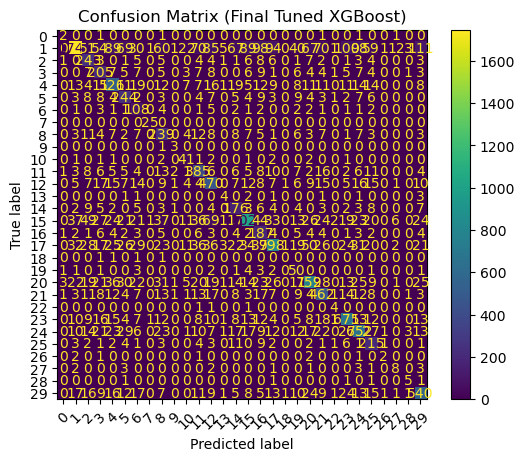

In [20]:

# Create directory
Path("../results/graphs").mkdir(parents=True, exist_ok=True)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot
disp = ConfusionMatrixDisplay(cm)
disp.plot(xticks_rotation=45)

plt.title("Confusion Matrix (Final Tuned XGBoost)")

# Save plot
plt.savefig("../results/graphs/confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()
plt.close()

## Error Analysis

### Overview
The confusion matrix reveals that the model performs strongly on high-support classes, with clear concentration along the diagonal. This indicates that the model is able to correctly learn dominant class patterns.

However, errors are not evenly distributed across all classes.

### Key Observations

- **Strong performance on majority classes**  
  Large diagonal values for certain classes show that the model consistently predicts well where sufficient training data is available.

- **Minority class confusion persists**  
  Several low-support classes exhibit scattered predictions across multiple classes, indicating unstable decision boundaries.

- **Class overlap and misclassification patterns**  
  Some classes are repeatedly misclassified into a small set of dominant classes, suggesting feature similarity or insufficient separability.

- **Near-zero predictions for rare classes**  
  A few classes still show very low true positive counts, confirming that extreme imbalance remains challenging even after tuning.

### Interpretation

The model has significantly improved its ability to detect minority classes compared to the baseline, as reflected in the higher macro F1 score. However, the confusion matrix shows that:

- Minority class predictions are still less confident and more dispersed  
- The model tends to map ambiguous or rare patterns into more frequent classes  
- Performance is constrained not only by model capacity but also by the underlying data distribution  

### Conclusion

The tuned XGBoost model with class weighting achieves strong overall and balanced performance, but residual errors are concentrated in low-support classes.

These results suggest that while class weighting and tuning improve fairness, further gains may require:

- additional data for rare classes  
- feature engineering to improve class separability  
- or advanced resampling techniques (e.g., SMOTE)  

Overall, the model demonstrates robust performance, with remaining errors primarily driven by data limitations rather than modelling deficiencies.

In [21]:
low_recall = report_df[report_df["recall"] < 0.3]
low_recall.sort_values(by="recall").head(10)

,precision,recall,f1-score,support
13,0.0000,0.0000,0.0000,14.0000
18,0.0000,0.0000,0.0000,5.0000
22,0.0000,0.0000,0.0000,7.0000
26,0.0000,0.0000,0.0000,10.0000
28,0.0000,0.0000,0.0000,10.0000
0,0.3333,0.1250,0.1818,8.0000
27,0.5000,0.1304,0.2069,23.0000
19,0.6957,0.2286,0.3441,70.0000


Several classes show near-zero recall, indicating the model fails to detect them entirely. 
These correspond to classes with very low support.

These classes are difficult to predict due to:
- extremely low number of training samples  
- overlap with features of dominant classes  
- insufficient representation for learning distinct patterns  

##  Model Interpretability

### Feature Importance

Feature importance provides a global view of which variables most influence the model's predictions.

The top features contribute significantly to decision-making, while many features have relatively low impact.

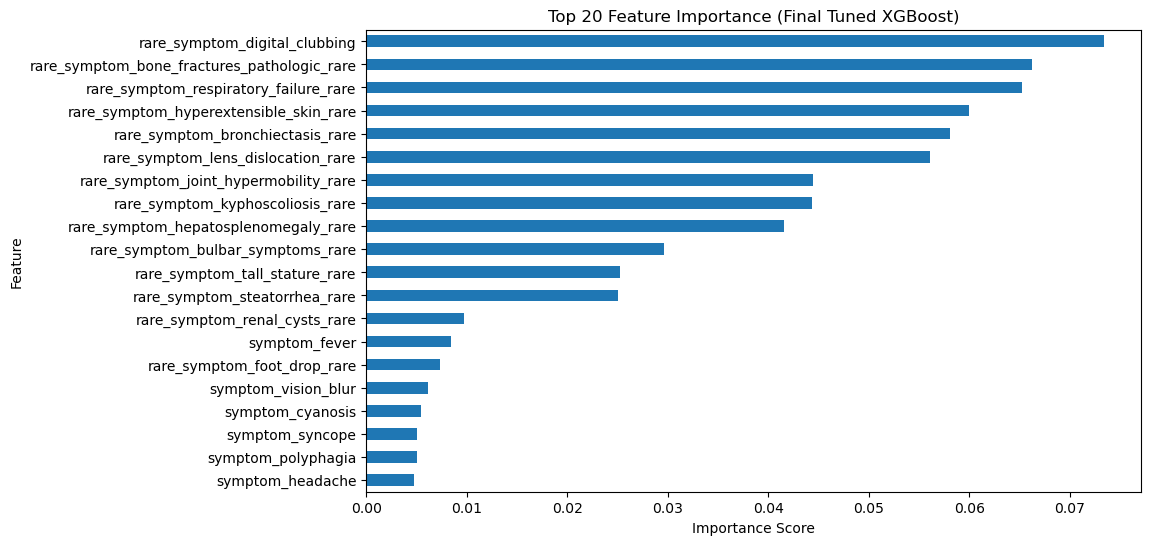

In [22]:

feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(20)

# Create directory
Path("../results/graphs").mkdir(parents=True, exist_ok=True)

# Plot top 20
plt.figure(figsize=(10, 6))

feature_importance.head(20).sort_values().plot(kind="barh")

plt.title("Top 20 Feature Importance (Final Tuned XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

# Save plot
plt.savefig("../results/graphs/feature_importance_top20.png", dpi=300, bbox_inches="tight")

plt.show()
plt.close()

## Feature Importance Insight (Rare Symptoms)

The model assigns relatively high importance to several rare symptom features, particularly:

- digital clubbing  
- pathologic bone fractures  
- respiratory failure  
- hyperextensible skin  

### Key Insight

Despite being rare in occurrence, these symptoms carry strong predictive signal and contribute significantly to the model’s decision-making.

### Interpretation

- These features likely have **high discriminative power**, meaning when they appear, they strongly indicate specific disease classes  
- The model is able to **leverage rare but informative features**, even in an imbalanced setting  
- This aligns with domain intuition, where certain rare symptoms are highly indicative of particular conditions  

### Implication

While overall performance is limited by data imbalance, the model is successfully identifying and utilizing **clinically meaningful features**, suggesting that feature quality is strong even where data quantity is limited.

From a practical perspective, the model relies on strong and unique symptoms to identify diseases.

If these key symptoms are not present, the model finds it difficult to make accurate predictions, 
which explains the lower performance on rare conditions.

---

### SHAP Analysis

SHAP values explain how each feature contributes to model predictions.

- Positive values increase the likelihood of a prediction  
- Negative values decrease it  

The summary plot shows:
- the most influential features overall  
- how feature values affect predictions across samples  

This provides both global and local interpretability of the model.

<Figure size 1600x800 with 0 Axes>

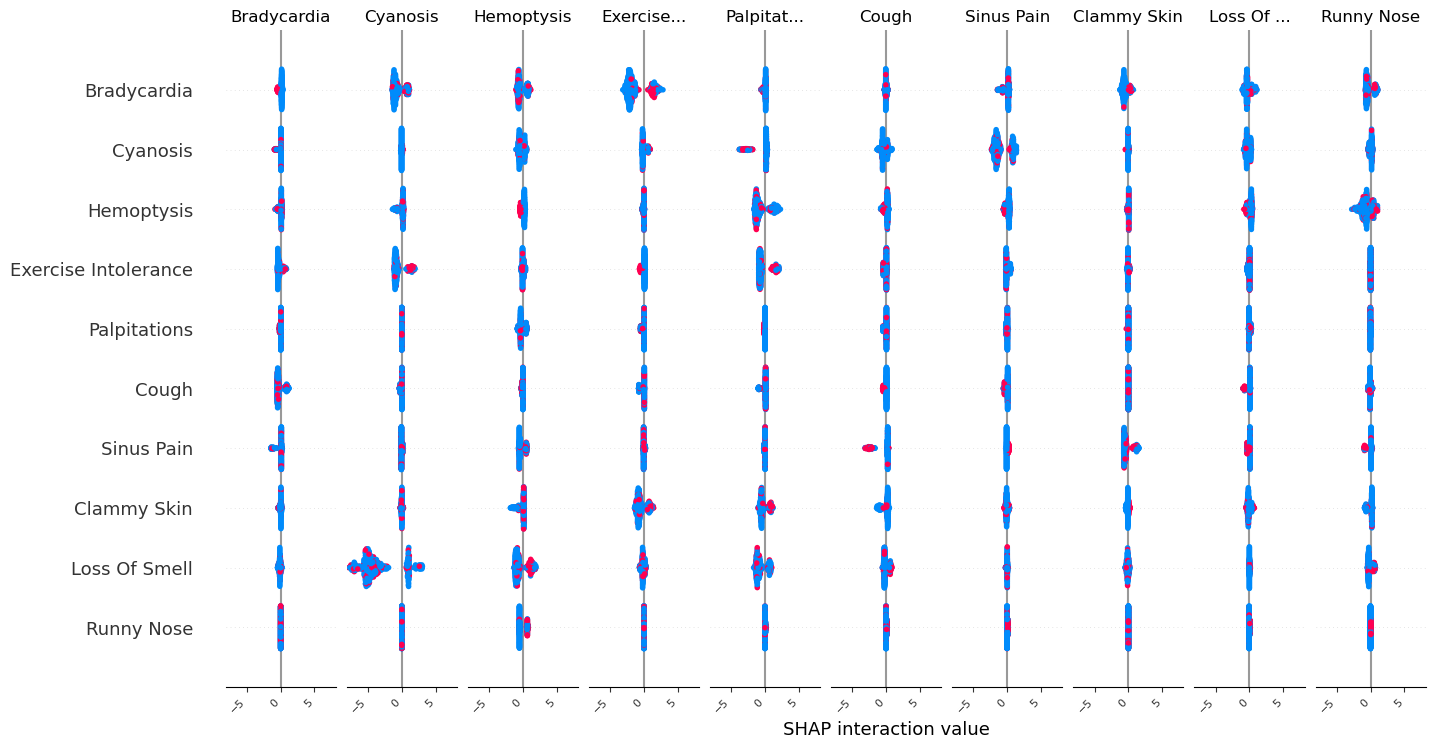

In [23]:
# =========================
# Imports
# =========================
from pathlib import Path
import shap
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Use final selected model
# =========================
final_model = search.best_estimator_

# =========================
# Load test data
# =========================
test_df = pd.read_csv("../data/processed/test.csv")

target_column = "disease_encoded"
X_test = test_df.drop(columns=[target_column])

# =========================
# Sample data for SHAP
# =========================
sample_size = 500

if len(X_test) > sample_size:
    X_sample = X_test.sample(n=sample_size, random_state=42)
else:
    X_sample = X_test.copy()

# =========================
# Build SHAP explainer
# =========================
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_sample)


# Save raw SHAP sample
X_sample.to_csv( "../results/tables/shap_sample.csv", index=False)

# =========================
# Clean feature names for plot
# =========================
X_sample_plot = X_sample.copy()
X_sample_plot.columns = [
    c.replace("symptom_", "").replace("_", " ").title()
    for c in X_sample_plot.columns
]

# =========================
# SHAP summary plot
# =========================
plt.figure(figsize=(16, 8))

shap.summary_plot(
    shap_values,
    X_sample_plot,
    show=False,
    max_display=10,
    plot_size=None
)

fig = plt.gcf()

for ax in fig.axes:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment("right")
        label.set_fontsize(8)

plt.subplots_adjust(top=0.88, bottom=0.15, left=0.25)

plt.savefig("../results/graphs/shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()


## Integrated Feature & Interaction Insights

### 1. Global Feature Importance (Model-Level)

The model consistently prioritizes a subset of clinically meaningful symptoms, including:

- Respiratory and cardiovascular indicators (e.g., cyanosis, palpitations, respiratory distress)
- Structural or systemic indicators (e.g., bone abnormalities, skin-related symptoms)
- High-signal rare symptoms (e.g., digital clubbing)

These features contribute most to reducing model loss and drive the primary decision boundaries.

---

### 2. SHAP Interaction Insights

The SHAP interaction plot reveals that:

- Most features exhibit **low interaction strength**, with values concentrated around zero  
- This indicates that the model primarily relies on **independent feature effects** rather than strong feature combinations  

However, a few patterns emerge:

- **Cyanosis and respiratory-related symptoms** show slightly wider spread → indicating interaction in disease differentiation  
- **Loss of smell and upper respiratory symptoms (e.g., runny nose)** show clustered interactions → suggesting co-occurrence patterns  
- **Exercise intolerance and palpitations** exhibit moderate interaction → likely capturing cardiovascular relationships  

---

### 3. Interpretation of Model Behavior

- The model behaves largely as an **additive learner**, where individual symptoms independently contribute to predictions  
- Limited interaction effects suggest that:
  - either features are already highly informative individually  
  - or the dataset lacks sufficient co-occurrence patterns to learn complex interactions  

---

### 4. Link to Error Analysis

This explains your earlier findings:

- **Minority class failures** persist not because features are weak  
- but because:
  - rare classes lack sufficient samples  
  - interaction patterns are not strongly learned  

Even when rare symptoms are important (from feature importance), the model:
- cannot reliably combine them into stable decision rules  

---

### 5. Key Insight

> The model relies more on strong individual symptom signals than on complex feature interactions, which limits its ability to distinguish rare or overlapping disease patterns.

---

### 6.  Conclusion

- Feature importance confirms that the model identifies clinically relevant predictors  
- SHAP interactions show that learning is mostly **additive rather than combinatorial**  
- Remaining performance limitations are **data-driven (imbalance + low co-occurrence)** rather than model-driven  

This reinforces that further improvements would require:
- richer data for rare classes  
- or techniques that enhance interaction learning (e.g., feature engineering, resampling)

----

## Practical Summary

The final tuned XGBoost model achieves strong overall performance, with improved macro F1-score indicating better balance across classes. It performs reliably for common diseases, where sufficient data enables the model to learn clear patterns.

However, performance remains limited for rare conditions. Even with class weighting and tuning, the model struggles to detect low-support classes, often misclassifying them as more frequent diseases. This reflects a fundamental data limitation rather than a modelling issue.

Feature importance and SHAP analysis show that the model relies on a small set of highly informative symptoms. When these signals are present, predictions are accurate; when absent, especially in rare cases, the model lacks sufficient evidence to make correct predictions.

In real-world healthcare settings, where data is inherently imbalanced and constrained by privacy and regulatory factors, this highlights that improving performance depends more on **data representation and coverage** than increasing model complexity.

---

## Final Conclusion

This study demonstrates that XGBoost, combined with class weighting and hyperparameter tuning, provides strong and consistent performance for multiclass disease prediction.

The final model achieves a substantial improvement in class-balanced performance (macro F1), confirming that imbalance-aware optimization is effective. However, persistent errors in minority classes show that model performance is ultimately constrained by the underlying data distribution.

Explainability analysis further reveals that the model is driven by a limited number of high-signal features and relies primarily on additive effects rather than complex feature interactions. This explains both its strengths (accurate predictions for well-represented classes) and its limitations (difficulty distinguishing rare or overlapping conditions).

Overall, the findings highlight that:
- Model optimization improves performance, but  
- **Data imbalance remains the dominant challenge**

Effective real-world deployment therefore requires not only strong models, but also better representation of rare conditions and interpretable decision support.

---

## Production Considerations

For deployment in real-world healthcare environments, the following considerations are critical:

- **Data Monitoring**  
  Continuously track class distribution to detect shifts and emerging imbalance over time  

- **Periodic Retraining**  
  Update the model with new data to maintain performance and adapt to changing patterns  

- **Robust Evaluation**  
  Validate on external datasets to ensure generalizability beyond the training environment  

- **Integration with Clinical Workflows**  
  Use the model as a decision-support tool, not a standalone system  

- **Explainability and Trust**  
  Maintain transparency through feature importance and SHAP-based explanations to support clinical interpretation  

---

## Final Wrap-Up

The model demonstrates strong practical value for common disease prediction and provides meaningful, interpretable insights into symptom importance.

However, its limitations in rare classes reinforce a key conclusion:

> Reliable multiclass disease prediction is not limited by model choice, but by data quality, balance, and representativeness.

Future improvements should therefore focus on enhancing data coverage and representation, alongside maintaining interpretable and robust modelling approaches.